
# PNEUMONIA DETECTION USING CNN
# Dataset: Chest X-Ray Pneumonia (Kaggle)



In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nandanarnair","key":"a2ea23a67dcc3bfb07df8fb32de6cfcc"}'}

In [3]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)

!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:22<00:00, 109MB/s]



In [5]:
!unzip -q chest-xray-pneumonia.zip

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [7]:
train_dir = "chest_xray/train"
val_dir = "chest_xray/val"
test_dir = "chest_xray/test"

In [8]:
print("Training Classes :", os.listdir(train_dir))
print("Validation Classes :", os.listdir(val_dir))
print("Testing Classes :", os.listdir(test_dir))

Training Classes : ['PNEUMONIA', 'NORMAL']
Validation Classes : ['PNEUMONIA', 'NORMAL']
Testing Classes : ['PNEUMONIA', 'NORMAL']


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
# Training Data Generator (with augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Validation Data Generator
val_datagen = ImageDataGenerator(rescale=1./255)

# Test Data Generator
test_datagen = ImageDataGenerator(rescale=1./255)

In [11]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

In [12]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.


In [13]:
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 16 images belonging to 2 classes.


In [14]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [15]:
print(train_generator.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


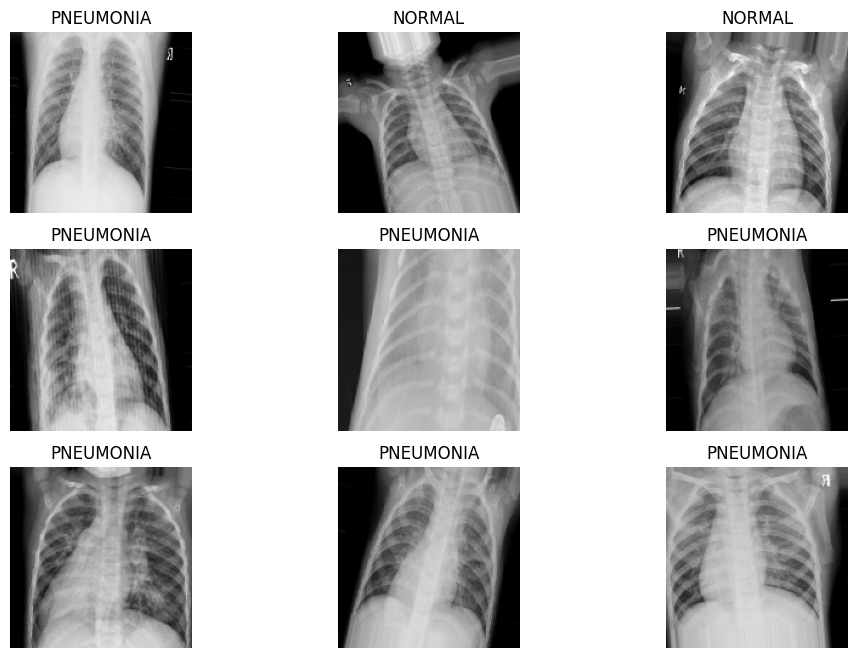

In [16]:
import matplotlib.pyplot as plt

images, labels = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title("PNEUMONIA" if labels[i]==1 else "NORMAL")
    plt.axis("off")

plt.show()

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

In [18]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,377 (18.42 MB)

 Trainable params: 4,828,929 (18.42 MB)

 Non-trainable params: 448 (1.75 KB)

In [20]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [21]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [22]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 460ms/step - accuracy: 0.8420 - loss: 0.7426 - val_accuracy: 0.5000 - val_loss: 45.9093
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 69s 425ms/step - accuracy: 0.8752 - loss: 0.2980 - val_accuracy: 0.5000 - val_loss: 42.4135
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 437ms/step - accuracy: 0.8917 - loss: 0.2993 - val_accuracy: 0.5000 - val_loss: 4.5622
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 433ms/step - accuracy: 0.9038 - loss: 0.2452 - val_accuracy: 0.5000 - val_loss: 7.6249
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 444ms/step - accuracy: 0.9062 - loss: 0.2189 - val_accuracy: 0.8125 - val_loss: 0.5710
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 427ms/step - accuracy: 0.9179 - loss: 0.2099 - val_accuracy: 0.5625 - val_loss: 1.4788
Epoch 7/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 436ms/step - accuracy: 0.9214 - loss: 0.1997 - val_accuracy: 0.5625 - val_loss: 1.1635
Epoch 8/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 428ms/step - accuracy: 0.9281 - loss:

In [23]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 230ms/step - accuracy: 0.8862 - loss: 0.3093
Test Loss: 0.3092671036720276
Test Accuracy: 0.8862179517745972


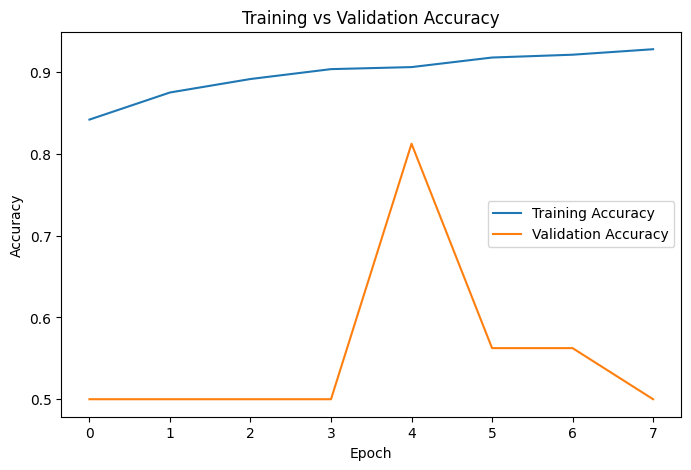

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

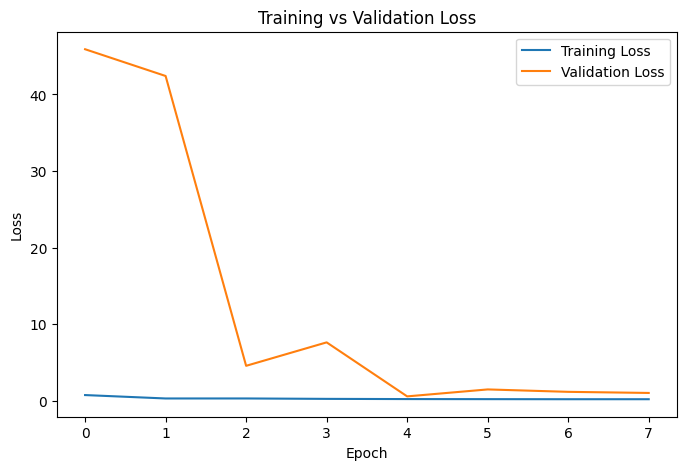

In [25]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [26]:
from sklearn.metrics import classification_report

predictions = model.predict(test_generator)

predictions = (predictions > 0.5).astype(int)

print(classification_report(
    test_generator.classes,
    predictions,
    target_names=['NORMAL', 'PNEUMONIA']
))

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 248ms/step
              precision    recall  f1-score   support

      NORMAL       0.90      0.78      0.84       234
   PNEUMONIA       0.88      0.95      0.91       390

    accuracy                           0.89       624
   macro avg       0.89      0.87      0.87       624
weighted avg       0.89      0.89      0.88       624



In [27]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(
    test_generator.classes,
    predictions
)

print(cm)

[[183  51]
 [ 20 370]]


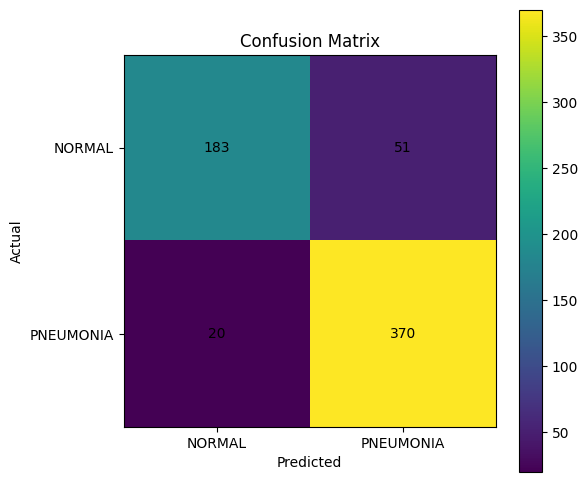

In [28]:
plt.figure(figsize=(6,6))

plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ['NORMAL', 'PNEUMONIA'])
plt.yticks(tick_marks, ['NORMAL', 'PNEUMONIA'])

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 750ms/step
Prediction: NORMAL


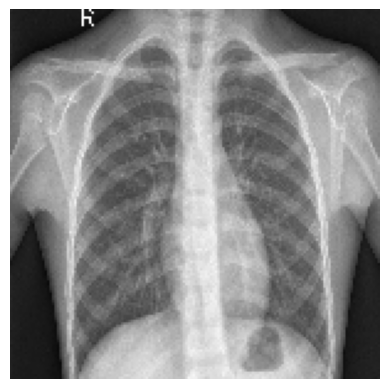

In [29]:
from tensorflow.keras.preprocessing import image
import numpy as np
img_path = "/content/chest_xray/test/NORMAL/IM-0001-0001.jpeg"

img = image.load_img(img_path, target_size=(150,150))

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Prediction: PNEUMONIA")
else:
    print("Prediction: NORMAL")
plt.imshow(img)
plt.axis("off")
plt.show()


In [30]:
model.save("pneumonia_cnn_model.h5")

print("Model Saved Successfully!")

Model Saved Successfully!


In [31]:
from tensorflow.keras.models import load_model

model = load_model("pneumonia_cnn_model.h5")